# Retail Sales Data Analysis

## OASIS INFOBYTE — Data Analytics Internship

### Exploratory Data Analysis (EDA)

## 1. Project Objective

The objective of this project is to perform exploratory data analysis on retail sales data to understand sales trends, customer demographics, product category performance, and relationships between numerical variables.

The analysis will help identify important business patterns and provide data-driven recommendations for improving sales performance.

## 2. Import Required Libraries

The following Python libraries are used for data manipulation, numerical analysis, and data visualization.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

## 3. Load the Dataset

The retail sales dataset is loaded into a pandas DataFrame for further analysis.

In [3]:
df = pd.read_csv("retail_sales_dataset.csv")

In [4]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 4. Initial Data Inspection

The dataset is inspected to understand its dimensions, column names, data types, and the presence of missing values.

In [5]:
df.shape

(1000, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [7]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## 5. Descriptive Statistics

Descriptive statistics are calculated for the numerical variables to understand their central tendency and variability.

The analysis includes:
- Mean
- Median
- Mode
- Standard deviation

In [8]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
numeric_columns = df.select_dtypes(include='number').columns

print("MEAN:")
print(df[numeric_columns].mean())

print("\nMEDIAN:")
print(df[numeric_columns].median())

print("\nMODE:")
print(df[numeric_columns].mode().iloc[0])

print("\nSTANDARD DEVIATION:")
print(df[numeric_columns].std())

MEAN:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

MEDIAN:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

MODE:
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

STANDARD DEVIATION:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


## 6. Sales Trend Analysis

Sales trends are analyzed at monthly and quarterly levels to identify periods of high and low sales performance.

In [10]:
df['Date'] = pd.to_datetime(df['Date'])


### 6.1 Monthly Sales Trend

Monthly sales are calculated to identify changes in sales performance over time.

In [11]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

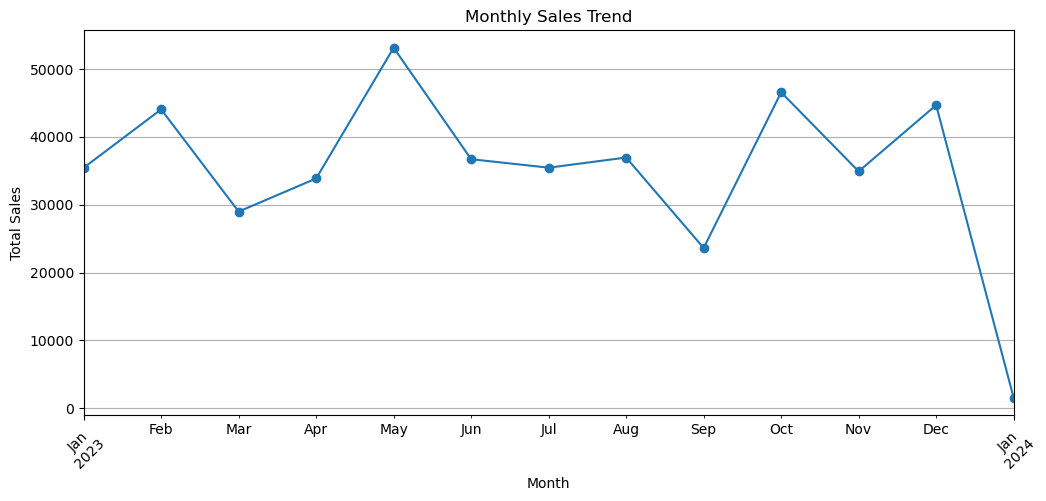

In [17]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### 6.2 Quarterly Sales Trend

Quarterly sales are analyzed to identify broader patterns in sales performance across different periods.

In [13]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

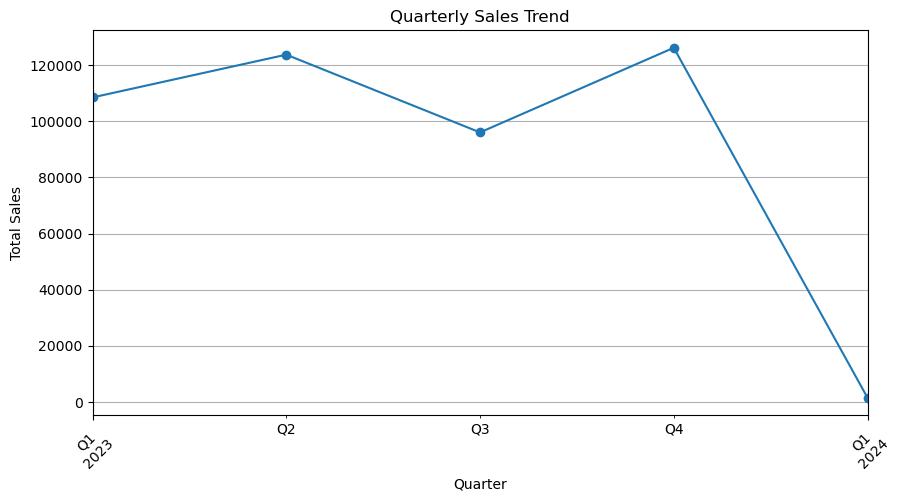

In [18]:
plt.figure(figsize=(10, 5))

quarterly_sales.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## 7. Customer Demographics

Customer demographics are analyzed using age groups and gender distribution to understand the composition of the customer base.

In [19]:
df['Age'].describe()

count    1000.00000
mean       41.39200
std        13.68143
min        18.00000
25%        29.00000
50%        42.00000
75%        53.00000
max        64.00000
Name: Age, dtype: float64

### 7.1 Age Group Analysis

Customers are grouped into age ranges to identify the most common customer segments in the dataset.

In [20]:
age_bins = [0, 20, 30, 40, 50, 60, 100]

age_labels = [
    'Under 20',
    '20-29',
    '30-39',
    '40-49',
    '50-59',
    '60+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

df['Age Group'].value_counts().sort_index()

Under 20     42
20-29       209
30-39       191
40-49       222
50-59       221
60+         115
Name: Age Group, dtype: int64

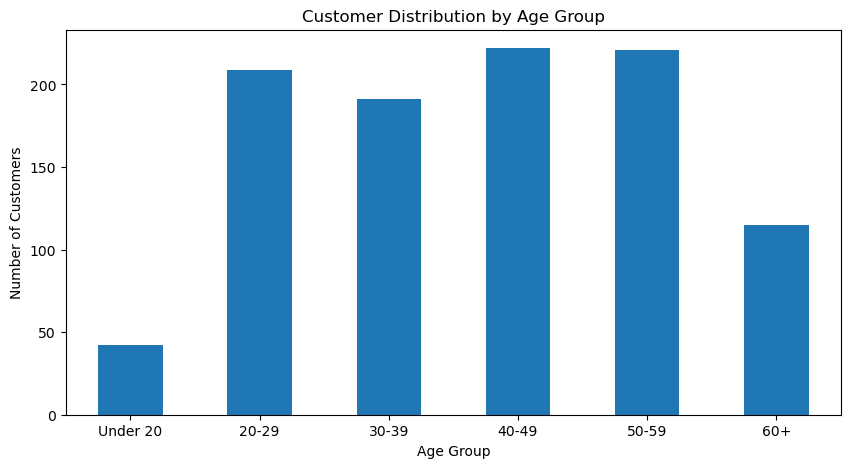

In [21]:
age_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

age_counts.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

### 7.2 Gender Analysis

Gender distribution is analyzed to understand the composition of customers and compare the number of customers across gender groups.

In [22]:
gender_counts = df['Gender'].value_counts()

gender_counts

Female    510
Male      490
Name: Gender, dtype: int64

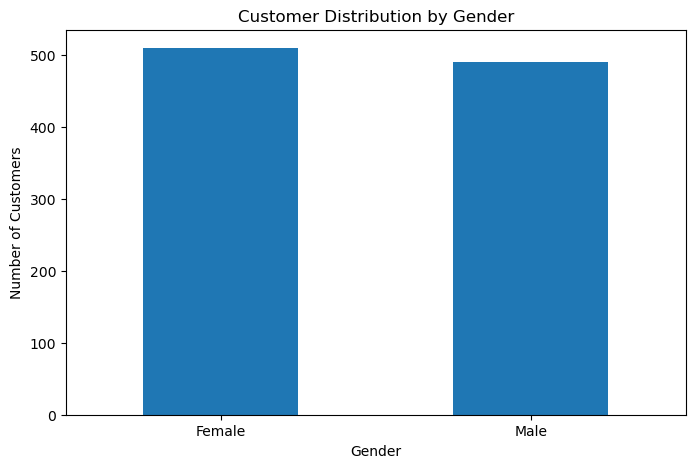

In [23]:
plt.figure(figsize=(8, 5))

gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()


## 8. Product Category Analysis

Product categories are analyzed based on revenue and quantity sold to identify the strongest-performing categories.

In [25]:
df.columns


Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Age Group'],
      dtype='object')

### 8.1 Revenue by Product Category

Total revenue is calculated for each product category to identify which category generates the highest sales value.

In [26]:
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

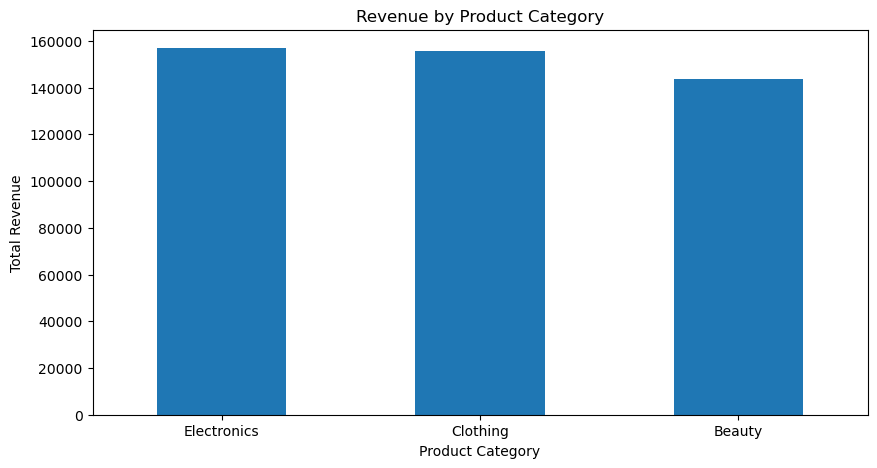

In [27]:
plt.figure(figsize=(10, 5))

category_sales.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.show()

### 8.2 Quantity Sold by Product Category

The total quantity sold is calculated for each product category to compare product demand across categories.

In [29]:
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

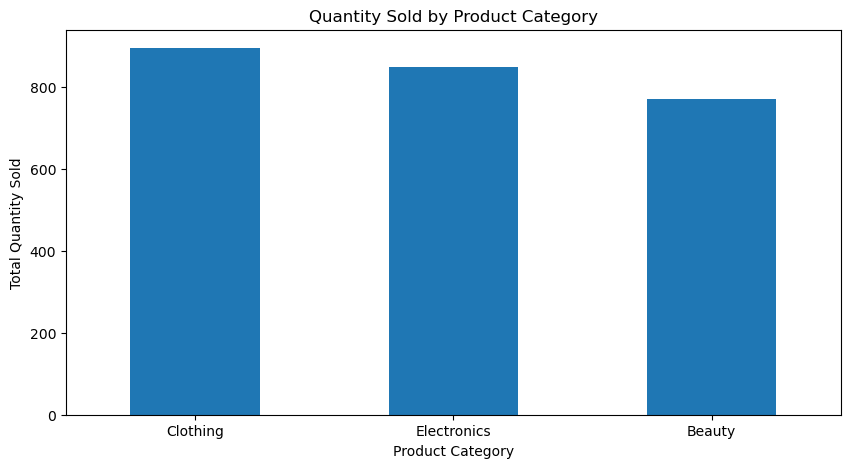

In [53]:
plt.figure(figsize=(10, 5))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)

plt.show()

## 9. Correlation Analysis

Correlation analysis is performed to understand relationships between numerical business variables such as age, quantity, price per unit, and total amount.

### 9.1 Correlation Heatmap

A correlation heatmap is used to visualize the strength and direction of relationships between numerical variables.

In [32]:
correlation_matrix = numeric_df.corr()

correlation_matrix

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


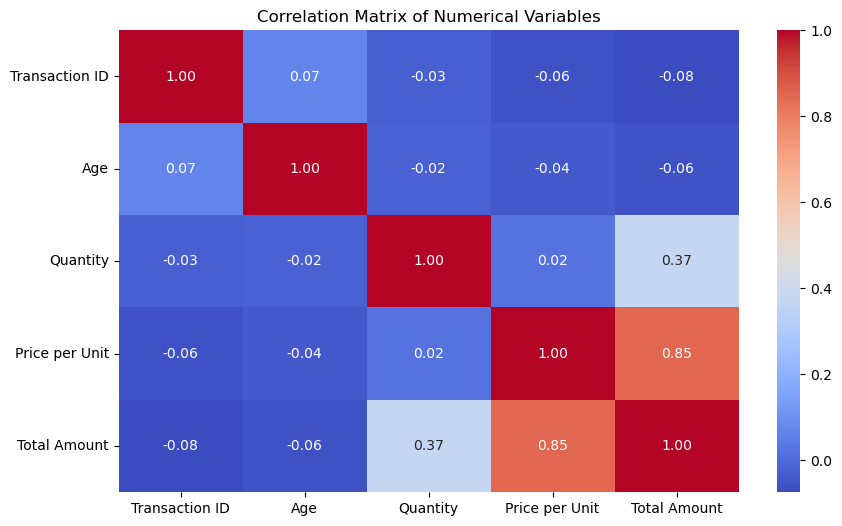

In [33]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

In [34]:
business_numeric = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
]

business_corr = business_numeric.corr()

business_corr

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


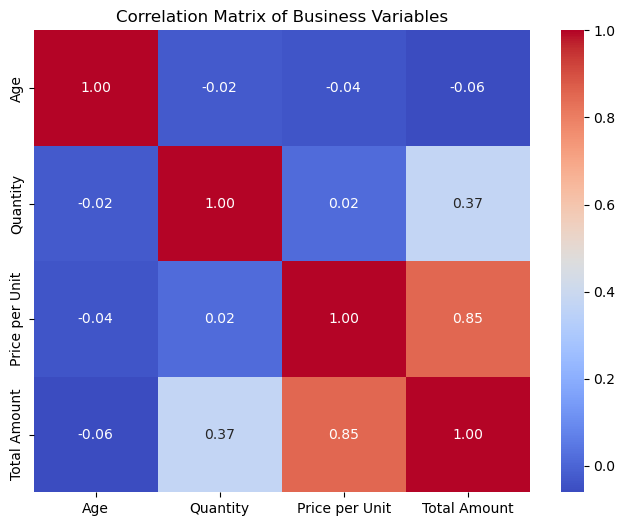

In [35]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    business_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Business Variables')

plt.show()

## 10. Additional Visualization

An additional visualization is created to examine total revenue generated by different gender groups.

In [36]:
gender_sales = df.groupby('Gender')['Total Amount'].sum().sort_values(ascending=False)

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

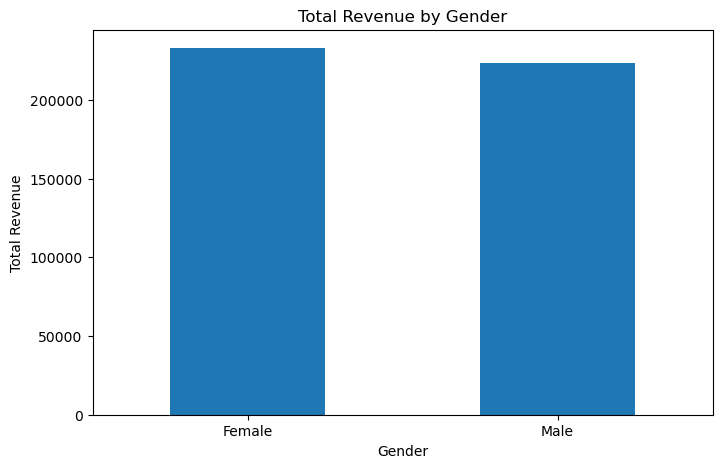

In [37]:
plt.figure(figsize=(8, 5))

gender_sales.plot(kind='bar')

plt.title('Total Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.show()

## 11. Key Insights

The following insights summarize the major findings obtained from the retail sales data analysis.

### 11.1 Business Insights

- Clothing generated the highest overall revenue among all product categories.
- Sales varied across different age groups, indicating differences in customer purchasing behavior.
- Male and female customers both contributed significantly to total revenue, with one gender generating slightly higher sales.
- Monthly revenue showed fluctuations, revealing seasonal trends in customer purchases.
- Correlation analysis indicated a strong positive relationship between Quantity and Total Amount.
- Product category performance and customer demographics provide useful information for business decision-making.

In [38]:
best_category = category_sales.idxmax()
best_category_revenue = category_sales.max()

print("Best-performing category:", best_category)
print("Revenue:", best_category_revenue)

Best-performing category: Electronics
Revenue: 156905


In [39]:
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

print("Highest-sales month:", best_month)
print("Sales:", best_month_sales)

Highest-sales month: 2023-05
Sales: 53150


In [40]:
lowest_month = monthly_sales.idxmin()
lowest_month_sales = monthly_sales.min()

print("Lowest-sales month:", lowest_month)
print("Sales:", lowest_month_sales)

Lowest-sales month: 2024-01
Sales: 1530


In [41]:
category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

In [42]:
gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

In [43]:
monthly_sales---

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

In [44]:
quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

In [45]:
age_counts

Under 20     42
20-29       209
30-39       191
40-49       222
50-59       221
60+         115
Name: Age Group, dtype: int64

In [46]:
business_corr

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


In [47]:
print("Highest-sales month:", best_month)
print("Highest sales:", best_month_sales)

print("Lowest-sales month:", lowest_month)
print("Lowest sales:", lowest_month_sales)

print("Best-performing category:", best_category)
print("Category revenue:", best_category_revenue)


Highest-sales month: 2023-05
Highest sales: 53150
Lowest-sales month: 2024-01
Lowest sales: 1530
Best-performing category: Electronics
Category revenue: 156905


## 12. Conclusion

This project analyzed retail sales data to identify customer purchasing patterns, product performance, and revenue trends. Through data cleaning, exploratory data analysis, visualization, and correlation analysis, valuable business insights were obtained. The results show that Electronics was the highest-performing product category, May 2023 recorded the highest monthly sales, and female customers contributed slightly more revenue than male customers. These findings can support better business planning, marketing strategies, and data-driven decision-making.